<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_1_2_MLR_Ames_Part2_ForwardBackward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames, Iowa: Forward and Backward Selection
## Classical Subset Selection with Cross-Validation

Part 1 left us with a cleaned dataset and a problem it created on purpose: **225 features**. Some of them are the backbone of any sensible price model; some are noise wearing a column name. Which are which?

The honest answer — try every possible subset and keep the best — is off the table: with 225 features there are $2^{225}$ subsets, a number comfortably larger than the count of atoms in the observable universe. Every feature-selection method is therefore a *shortcut through an impossibly large search space*, and the interesting question about each method is what the shortcut costs.

This notebook works through the classical shortcuts:

1. **Shortlist** the 225 features down to ~40 candidates with a correlation filter (a fast, flawed first cut)
2. Run **forward selection** — start empty, hire features one at a time
3. Run **backward selection** — start full, fire features one at a time
4. Interpret the winning model's coefficients, then stress-test them with **VIF** multicollinearity diagnostics

**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Dict, Any
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Download the cleaning module from GitHub
import urllib.request
module_url = "https://raw.githubusercontent.com/bsheese/cs377/main/17_regression_crossval/17_2_MLR/ames_cleaning.py"
urllib.request.urlretrieve(module_url, "ames_cleaning.py")
from ames_cleaning import load_and_clean_ames

data_url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'
X_train, X_test, y_train, y_test = load_and_clean_ames(data_url)
print(f"Cleaned X_train shape: {X_train.shape}")
print(f"Cleaned X_test shape: {X_test.shape}")

Cleaned X_train shape: (2340, 225)
Cleaned X_test shape: (585, 225)


/home/qwerty/repos/publiccourses/377/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### Step 1: Feature Shortlisting (The Speed-Up)

With ~225 features, running Forward Selection can take 20+ minutes on a standard laptop. Backward Selection would take even longer. To make the runtime practical, we pre-filter the candidate set using a correlation filter.

**The Correlation Filter:** We calculate the absolute Pearson correlation between every feature and `Log_SalePrice`, then keep only the top 40 highest-scoring features to pass into the selector.

This shortcut comes with two important limitations:

1. **Categorical Bias:** Pearson correlation is designed for continuous variables. One-hot encoded dummy variables (like neighborhood indicators) often show low correlation coefficients simply because they contain mostly zeros — even when that neighborhood adds a large price premium. The filter may silently discard valuable location signals.

2. **Redundancy Trap:** The filter looks at one variable at a time and does not know that two features might carry the same information. We could hand the Stepwise Selector a shortlist full of collinear candidates. The SFS will partially sort this out, but its job becomes harder.

In [2]:
# 1. Calculate absolute correlation of all features with the target
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)

# 2. Keep the top 40 features as candidates for selection
shortlist = correlations.head(40).index.tolist()

print(f"Shortlisted {len(shortlist)} features for the selection process.")
print("\nTop 10 shortlisted features:")
print(correlations.head(10))

# Create the shortlisted datasets
X_train_short = X_train[shortlist]
X_test_short = X_test[shortlist]

Shortlisted 40 features for the selection process.

Top 10 shortlisted features:
Overall Qual            0.821216
Total_Square_Footage    0.810943
Log_Gr Liv Area         0.723679
Exter Qual              0.672535
Garage Cars             0.665823
Kitchen Qual            0.663423
Garage Area             0.639331
Bsmt Qual               0.627917
Year Built              0.608763
Garage Finish           0.584370
dtype: float64



**Transitioning from Correlation to Stepwise Selection**

Now that we have reduced our feature set from 200+ down to 40, we have a manageable 'candidate pool.' The **Sequential Feature Selector (SFS)** will now take over to do what the correlation filter could not: identify **unique** contributions.

While the correlation filter just looked for 'high scores,' the SFS will look for 'teamwork.' It will evaluate how much *new* information a variable adds to the variables already in the model. This is where we hope to fix the 'Redundancy Trap' mentioned above. If we have two highly correlated variables in our top 40, the SFS should (ideally) realize that adding the second one doesn't significantly improve the model's $R^2$ and will leave it out.

**What to watch for:** As you look at the final features chosen by the SFS, ask yourself: Are there any neighborhoods left? If the final model is dominated only by square footage and room counts, it is a sign that our initial Correlation Filter may have been too aggressive in stripping away the categorical data.



## Implementing Forward and Backward Selection

Instead of guessing which features matter, we let the data tell us. These algorithms search through possible feature combinations using cross-validation to evaluate each one.

### Notes on `perform_feature_selection_and_evaluation()`

The function packages three steps into a single **Pipeline**:
1. **Scales** the data with `StandardScaler` so different units can be compared fairly. Placing the scaler inside the pipeline ensures it is fit only on the training folds during CV, preventing data leakage.
2. Applies a **Sequential Feature Selector** that auditions variables one by one and keeps the ones that add unique predictive value beyond what is already in the model.
3. Fits a **Linear Regression** on the selected features only.

**On `n_features_to_select='auto'`:** Rather than requiring a fixed target count, `'auto'` uses a heuristic: it stops adding (or removing) features when the CV improvement from the next candidate falls below half the standard deviation of recent CV scores. The resulting count adapts to the data and is not a principled stopping criterion. Part 4 introduces `GridSearchCV` to control this more explicitly.

**On the displayed coefficients:** The function runs cross-validation to get an honest R², then fits the pipeline a second time on the full training set to extract selected features and coefficients. These two fits may produce slightly different feature subsets — the CV R² and the displayed coefficients come from separate model fits.

In [3]:
def perform_feature_selection_and_evaluation(
    X: pd.DataFrame,
    y: pd.Series,
    selection_direction: str = 'forward',
    cv_folds: int = 5
) -> Dict[str, Any]:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SequentialFeatureSelector(
            LinearRegression(),
            n_features_to_select='auto',  # stops when CV gain < 0.5 * score std
            direction=selection_direction,
            cv=cv_folds
        )),
        ('model', LinearRegression())
    ])

    scoring_metrics = ['r2', 'neg_mean_squared_error']
    # return_train_score=True exposes the train/CV gap — the direct overfitting diagnostic
    cv_results = cross_validate(pipeline, X, y, cv=cv_folds, scoring=scoring_metrics,
                                return_train_score=True)

    train_r2 = cv_results['train_r2']
    cv_r2 = cv_results['test_r2']

    # Refit on full training data to extract selected features and coefficients.
    # This is a separate fit from CV and may select a slightly different subset.
    pipeline.fit(X, y)

    selected_mask = pipeline.named_steps['selector'].get_support()
    selected_feature_names = X.columns[selected_mask].tolist()

    coefficients = pipeline.named_steps['model'].coef_

    coef_df = pd.DataFrame({
        'Feature': selected_feature_names,
        'Coefficient': coefficients
    }).sort_values(by='Coefficient', ascending=False)

    print(f"Train R² (avg fold):  {train_r2.mean():.4f} ± {train_r2.std():.4f}")
    print(f"CV R²:                {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"Train-CV gap:         {train_r2.mean() - cv_r2.mean():.4f}  (positive = some overfitting)")

    return {
        'model_pipeline': pipeline,
        'selected_features': selected_feature_names,
        'coefficients': coef_df,
        'cv_r2_mean': cv_r2.mean(),
        'train_r2_mean': train_r2.mean(),
        'final_model': pipeline.named_steps['model']
    }

## Notes on `run_modeling_workflow()`

This function is the master controller for one full experiment. It runs the feature-selection process on the training data to build a model, then immediately gives that model its final exam: predicting prices for the held-out test set it has never seen.

To help you read the results, it also draws a **residual plot** — a visual health check. Errors scattered randomly around the red center line mean the model is behaving; any visible shape or pattern means it is systematically missing something. The function ends with a full report card: the selected features, the final scores, and that diagnostic map of its mistakes.

In [4]:
def run_modeling_workflow(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    selection_direction: str = 'forward',
    cv_folds: int = 5,
    plot_residuals: bool = True
) -> Dict[str, Any]:
    print(f"--- Running {selection_direction.upper()} Selection ---")
    results = perform_feature_selection_and_evaluation(
        X=X_train, y=y_train,
        selection_direction=selection_direction, cv_folds=cv_folds
    )

    final_model = results['model_pipeline']
    test_predictions = final_model.predict(X_test)
    test_r2 = r2_score(y_test, test_predictions)

    print(f"Test R² (held-out):   {test_r2:.4f}")

    # Coefficients are standardized beta weights (features were scaled by StandardScaler).
    # Multiply by 100 for the approximate % effect on sale price per 1-SD change in that feature.
    print(f"\nFinal Model Coefficients — standardized beta weights (top 10):")
    print(results['coefficients'].head(10).to_string(index=False))
    print(f"\nFinal Model Coefficients (bottom 10):")
    print(results['coefficients'].tail(10).to_string(index=False))

    print(f"\nSelected {len(results['selected_features'])} features.")

    if plot_residuals:
        residuals = y_test - test_predictions
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=test_predictions, y=residuals, alpha=0.5)
        plt.axhline(0, color='red', linestyle='--')
        plt.title(f'{selection_direction.capitalize()} Selection Residuals')
        plt.show()

    return results

## Forward Selection (Start Empty, Add Features)

Forward selection runs like an audition. The model starts with nothing but an intercept — literally predicting the average price for every house, our old baseline from 17_0:

$$\text{SalePrice} = \beta_0$$

Then round one: each of the 40 candidates gets a solo audition. Fit a one-feature model with `Overall Qual`, cross-validate it; fit one with `Total_Square_Footage`, cross-validate it; and so on through all 40. The feature whose model posts the best CV score is hired — permanently.

Round two: the remaining 39 candidates audition again, but now *alongside the first hire*. The question has changed in an important way: it's no longer "which feature is best?" but "which feature adds the most *on top of what the model already knows*?" A feature that duplicates the first hire's information will add almost nothing and score poorly, however good it looked solo. The best teammate is hired; then round three with 38, and so on.

Notice the cost accumulating: 40 CV evaluations, then 39, then 38... selecting 20 features means roughly 600 cross-validated model fits. That's the price of this search *after* shortlisting — run it on all 225 features and you're back to the 20-plus-minute (or 90-minute, with full CV) territory that motivated the correlation filter.

**When does it stop?** With `n_features_to_select='auto'`, sklearn stops when the CV gain from the next hire drops below half the standard deviation of recent scores. It's a reasonable heuristic — not a principled criterion. Part 4 replaces it with something better.

**The catch, and it's the big one:** forward selection is **greedy**. Every hire is permanent. A feature that looked great in round two can never be reconsidered in light of what got hired in round ten, even if it's now redundant. The search follows one locally-best path through the subset space and never looks back — good model, no guarantee of the best one.

--- Running FORWARD Selection ---


Train R² (avg fold):  0.8903 ± 0.0050
CV R²:                0.8842 ± 0.0194
Train-CV gap:         0.0061  (positive = some overfitting)
Test R² (held-out):   0.9325

Final Model Coefficients — standardized beta weights (top 10):
             Feature  Coefficient
        Overall Qual     0.112967
Total_Square_Footage     0.075048
     Log_Gr Liv Area     0.063776
        BsmtFin SF 1     0.042522
        Log_Lot Area     0.040195
      Year Remod/Add     0.034499
       Central Air_Y     0.025083
        Kitchen Qual     0.022548
          Heating QC     0.020091
          Fireplaces     0.019890

Final Model Coefficients (bottom 10):
             Feature  Coefficient
          Year Built     0.018644
         Garage Cars     0.017756
          Exter Qual     0.017599
      Garage Cond_TA     0.017175
       Paved Drive_Y     0.013986
        Wood Deck SF     0.008673
Neighborhood_NridgHt     0.007717
       Lot Shape_Reg    -0.006603
      MS SubClass_30    -0.011258
        MS Zoning_

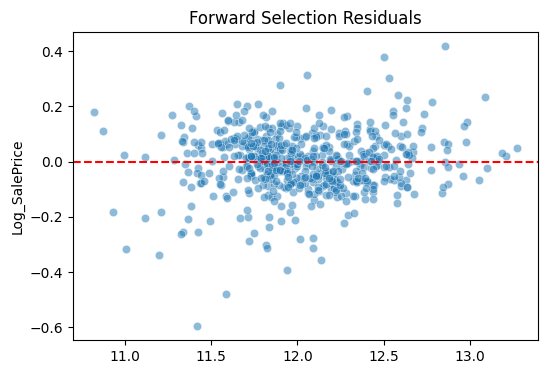

In [5]:
forward_results = run_modeling_workflow(
    X_train_short, X_test_short, y_train, y_test,
    selection_direction='forward', cv_folds=5
)

Forward selection has run. Note the selected features, the train/CV R² gap, and the test R² above. Now run backward selection — which starts from the complete 40-feature set and removes the weakest feature at each step — and we will compare both results afterward.

## Backward Selection (Start Full, Remove Features)

Backward selection is the same audition run in reverse — a layoffs process rather than a hiring one. Start with all 40 shortlisted features in the model. Each round, try firing each remaining feature one at a time, cross-validating every reduced model, and permanently remove the feature whose absence hurts CV performance the least. Stop when every remaining feature would be genuinely missed.

The direction change has real consequences:

| | Forward | Backward |
|---|---|---|
| Starting point | Empty model | Full model |
| Each step | Add best feature | Remove weakest feature |
| Advantage | Fast, handles large candidate sets | Sees features in full context — can keep teams forward would never assemble |
| Limitation | Cannot undo an early addition | More expensive; cannot undo an early removal |

The "full context" advantage is worth a sentence: because backward selection starts with everything, two features that are only useful *together* get evaluated together from the start. Forward selection can miss such a pair entirely — neither member auditions well solo, so neither ever gets hired. Backward also costs more: its early rounds cross-validate models with nearly all 40 features, and big models are slower to fit.

The fine print is unchanged: backward is just as **greedy** as forward. Every firing is final. Both are practical heuristics for walking a tiny, plausible path through those $2^{225}$ subsets — which is why running *both* and comparing answers is about to be informative.

--- Running BACKWARD Selection ---


Train R² (avg fold):  0.8903 ± 0.0050
CV R²:                0.8836 ± 0.0192
Train-CV gap:         0.0068  (positive = some overfitting)
Test R² (held-out):   0.9331

Final Model Coefficients — standardized beta weights (top 10):
             Feature  Coefficient
        Overall Qual     0.110818
     Log_Gr Liv Area     0.068029
Total_Square_Footage     0.067853
        Log_Lot Area     0.043859
        BsmtFin SF 1     0.041422
      Year Remod/Add     0.034816
       Central Air_Y     0.023560
        Kitchen Qual     0.023000
          Heating QC     0.020676
          Fireplaces     0.020026

Final Model Coefficients (bottom 10):
             Feature  Coefficient
          Year Built     0.019741
          Exter Qual     0.019284
         Garage Cars     0.018717
      Garage Cond_TA     0.016861
           Bsmt Qual     0.014775
       Paved Drive_Y     0.013423
        Wood Deck SF     0.008150
Exterior 2nd_VinylSd    -0.008229
      MS SubClass_30    -0.010940
        MS Zoning_

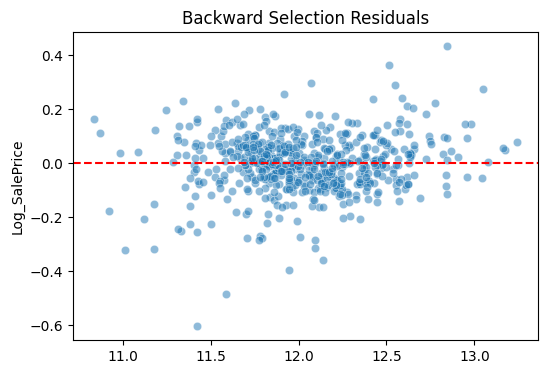

In [6]:
backward_results = run_modeling_workflow(
    X_train_short, X_test_short, y_train, y_test,
    selection_direction='backward', cv_folds=5
)

## Comparing Forward and Backward Results

When two search strategies starting from opposite ends of the feature space converge on similar answers, that is strong evidence the selection is stable. Let's check how much forward and backward agree:

In [7]:
forward_set = set(forward_results['selected_features'])
backward_set = set(backward_results['selected_features'])

print(f"Forward selected:  {len(forward_set)} features")
print(f"Backward selected: {len(backward_set)} features")
print(f"Features in both:  {len(forward_set & backward_set)}")
print(f"Overlap rate:      {len(forward_set & backward_set) / len(forward_set | backward_set):.0%}")
print(f"\nIn forward only:  {sorted(forward_set - backward_set) or 'none'}")
print(f"In backward only: {sorted(backward_set - forward_set) or 'none'}")

Forward selected:  20 features
Backward selected: 20 features
Features in both:  18
Overlap rate:      82%

In forward only:  ['Lot Shape_Reg', 'Neighborhood_NridgHt']
In backward only: ['Bsmt Qual', 'Exterior 2nd_VinylSd']


## Interpreting Our Results

The comparison above shows how much forward and backward selection agree. When two search strategies starting from opposite ends of the feature space converge on similar features, that is strong evidence the selection is stable — the result reflects the data's signal rather than the search direction. We will interpret the backward selection model in detail below.

### 1. Model Performance ($R^2$)

*   **The Score:** A Final Test $R^2$ of **~0.93** means the model explains about 93% of the variance in house prices on held-out data. In real estate modeling this is very strong.
*   **Test R² vs. CV R²:** Test R² slightly exceeds CV R² (~0.88). This is expected, not evidence of exceptional generalization. The fixed test set played no role in any decision — feature selection, scaling, and fitting all happened entirely on training data. The test split happened to be a favorable random draw. CV R² is the more reliable estimate because it averages across five different held-out folds rather than relying on one split.

> **Preview:** Because feature selection was tuned on training data and evaluated on a single fixed test set, this test R² is optimistic. Part 4 introduces **Nested Cross-Validation** to get a fully unbiased performance estimate when selection and evaluation share the same data pool.

### 2. The "Big Three" Value Drivers

Because the pipeline includes a `StandardScaler`, the coefficients are **standardized beta weights**. To interpret them: **multiply by 100 for the approximate percentage effect on sale price per one-standard-deviation change in that feature.** A coefficient of 0.11 for `Overall Qual` means a one-SD jump in quality is associated with roughly an 11% increase in sale price.

*   **Quality is King:** `Overall Qual` is the strongest predictor.
*   **Size is Queen:** `Total_Square_Footage` and `Log_Gr Liv Area` are next. Even after controlling for quality, raw living space is a massive driver of price.
*   **Efficiency Matters:** `BsmtFin SF 1` (finished basement area) is notably high — a finished basement adds more value than most secondary features like a deck or porch.

### 3. Logic Check: Positive vs. Negative Impact

*   **Value Adders (+):** `Central Air_Y` and `Kitchen Qual` confirm that modern convenience and high-end finishes command a clear price premium.
*   **Value Subtractors (-):** `MS SubClass_30` refers to older 1-story homes built before 1945; `MS Zoning_RM` refers to high-density residential zones. The model correctly identifies these as price anchors.

### 4. The Selection Efficiency

Backward Selection started with ~40 variables and narrowed to ~20 — roughly halving the feature count without meaningful loss in predictive power.

### 5. Summary Story for a Client

> "Our model predicts house prices with ~93% accuracy. The strongest levers for increasing value are **Overall Quality** and **Kitchen Quality**, or finishing a **Basement**. Being in a **Medium Density (RM) zone** or being an **older 1-story home (SubClass 30)** acts as a price anchor regardless of other features."

---

### Assessing Multicollinearity with VIF

Now that our model has selected its favorite features, we check for **Multicollinearity**. If two features overlap too much, their individual coefficients become unreliable.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X: pd.DataFrame):
    X_with_const = X.assign(const=1)
    vif_data = []
    for i, col in enumerate(X.columns):
        vif_value = variance_inflation_factor(X_with_const.values, i)
        vif_data.append({'Feature': col, 'VIF': vif_value})
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Run VIF on the features selected by Backward Selection
final_features = backward_results['selected_features']

# Filter out dummies for cleaner VIF interpretation
numeric_final = [f for f in final_features if X_train[f].nunique() > 2]

print("VIF for selected continuous/ordinal features:")
print(calculate_vif(X_train[numeric_final]))

VIF for selected continuous/ordinal features:
                 Feature       VIF
1   Total_Square_Footage  6.567843
2        Log_Gr Liv Area  4.882148
0           Overall Qual  3.550912
3             Exter Qual  2.908433
5           Kitchen Qual  2.519113
7             Year Built  2.330728
6              Bsmt Qual  2.322106
8         Year Remod/Add  2.209876
4            Garage Cars  1.913692
9             Heating QC  1.607318
11          BsmtFin SF 1  1.440527
10            Fireplaces  1.403966
12          Log_Lot Area  1.358461
13          Wood Deck SF  1.160437


These results are a "health check" for multicollinearity. In MLR, we want features to be related to the target, but not too related to each other.

### 1. Interpreting VIF: "The Overlapping Signals"

A VIF of **1** means no correlation with other features. Common thresholds:
*   **VIF < 5:** Generally safe.
*   **VIF 5–10:** High multicollinearity; coefficients becoming unstable.
*   **VIF > 10:** Severe; consider removing or combining the feature.

**The specific conflict here:**
`Total_Square_Footage` and `Log_Gr Liv Area` are clearly redundant — `Gr Liv Area` is 1st + 2nd floor area, which is a subset of `Total_Square_Footage` (which also includes the basement). We are telling the model how big the house is twice.

### 2. Why this is a problem

A high VIF does not hurt predictive R², but it makes individual coefficients unreliable. When two features move together, OLS cannot decide which one deserves the credit for a price change. One coefficient may be artificially inflated, the other deflated — neither can be interpreted at face value.

### 3. Recommended Steps

**Step 1: Drop one of the "Size" variables.**
Keep `Total_Square_Footage` as the "master size" variable. Remove `Log_Gr Liv Area`. After dropping, the remaining size variable should fall to a VIF near 2.0.

**Step 2: Monitor `Overall Qual` and `Year Built`.**
Their VIFs (roughly 2–4) are in the healthy range. Newer houses often have higher quality scores, so watch for creep — as long as both stay below 5.0, no action is needed.

### Summary of the Next Move

We will remove `Log_Gr Liv Area` and keep `Total_Square_Footage`. The model should retain nearly the same R² while producing more stable, trustworthy coefficients.

> **Scope note:** This fix applies only to `X_train_short` and `X_test_short` — the local shortlisted dataset used in this notebook. When Part 3 loads the full 225-feature dataset from `ames_cleaning.py`, both columns will be present again. Part 3 handles their overlap differently: Ridge regression shrinks both columns simultaneously rather than deleting one.

--- Running BACKWARD Selection ---


Train R² (avg fold):  0.8880 ± 0.0053
CV R²:                0.8803 ± 0.0207
Train-CV gap:         0.0077  (positive = some overfitting)
Test R² (held-out):   0.9291

Final Model Coefficients — standardized beta weights (top 10):
             Feature  Coefficient
        Overall Qual     0.115563
Total_Square_Footage     0.113339
        Log_Lot Area     0.045465
        BsmtFin SF 1     0.037649
      Year Remod/Add     0.036754
       Central Air_Y     0.024514
          Fireplaces     0.023944
        Kitchen Qual     0.023046
          Heating QC     0.019788
         Garage Cars     0.019502

Final Model Coefficients (bottom 10):
             Feature  Coefficient
           Half Bath     0.019034
      Garage Cond_TA     0.017799
          Exter Qual     0.017528
           Full Bath     0.017274
       Paved Drive_Y     0.016004
    Foundation_PConc     0.014195
        Wood Deck SF     0.009115
Exterior 2nd_VinylSd    -0.009065
        MS Zoning_RM    -0.013411
      MS SubClass_

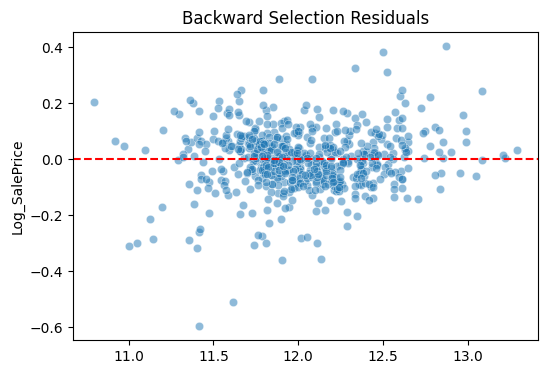

In [9]:
X_train_short = X_train_short.drop(columns='Log_Gr Liv Area')
X_test_short = X_test_short.drop(columns='Log_Gr Liv Area')

backward_results = run_modeling_workflow(
    X_train_short, X_test_short, y_train, y_test,
    selection_direction='backward', cv_folds=5
)

## Summary

By using **Correlation Filtering** to shortlist candidates, we reduced the runtime of feature selection from 20+ minutes to under a minute.

1. **Both search directions agreed:** Forward and backward selection converged on nearly the same ~20-feature set, confirming the selection is stable rather than an artifact of search direction.
2. **Strong performance:** The shortlisted-SFS approach achieved ~0.93 test R² using only ~20 features out of 225.
3. **VIF diagnostics** revealed that `Total_Square_Footage` and `Log_Gr Liv Area` substantially overlap. Dropping one stabilized the coefficients for this shortlisted model. This fix is local — the full dataset in Part 3 retains both columns, and regularization handles their overlap through shrinkage rather than deletion.
4. **Log-transformed coefficients** are interpretable as approximate percentage effects: multiply a standardized beta weight by 100 to get the rough % impact on sale price per one-standard-deviation change in that feature.

### Limitations of this approach

The correlation filter is biased against categorical (one-hot encoded) features, so neighborhood information was likely lost before selection even started. Stepwise selection is also greedy and irrevocable — the final feature set is locally optimal at each step but not guaranteed to be globally best.

### What's next: Part 3

Part 3 takes a fundamentally different approach: **regularization (Ridge, Lasso, ElasticNet)** works with all 225 features simultaneously. Rather than discarding features upfront, it shrinks their coefficients — some close to zero (Lasso drops them entirely). No pre-filter, no step-by-step greedy search.

The open question: can regularization on all 225 features match or beat the ~0.93 R² we just achieved with a manual 40-feature shortlist?